# Лабораторная работа 1: Линейная и гребневая регрессия, PCA

## Введение

Цель лабораторной работы — изучить основы линейной регрессии и гребневой регрессии (Ridge), 
построить и обучить модели на реальном датасете землетрясений, оценить качество моделей с помощью 
метрик RMSE, R² и MAPE, а также исследовать влияние мультиколлинеарности признаков и влияние снижения 
размерности методом главных компонент (PCA) на качество предсказаний.

Основные задачи работы:

- загрузить датасет землетрясений и выполнить первичный анализ данных;
- визуализировать распределения признаков и целевой переменной;
- провести предобработку данных: обработку пропусков, нормализацию, разделение на train/test;
- построить линейную и гребневую регрессионные модели, выполнить кросс-валидацию и оценить качество по метрикам;
- исследовать наличие мультиколлинеарности (матрица корреляций, VIF);
- выполнить снижение размерности методом PCA и повторно обучить модели на главных компонентах, сравнив качество с моделями на исходных признаках.


## Теоретические сведения

### Линейная регрессия

Линейная регрессия описывает зависимость целевой переменной $y$ от набора признаков $x_1, \dots, x_p$ в виде линейной модели:
$$
y \approx \hat{y} = w_0 + w_1 x_1 + \dots + w_p x_p = \mathbf{x}^\top \mathbf{w}.
$$

В матричном виде для выборки из $n$ объектов:
$$
\hat{\mathbf{y}} = X \mathbf{w},
$$
где $X$ — матрица признаков размера $n \times p$, $\mathbf{w}$ — вектор весов модели.

Оценка параметров выполняется методом наименьших квадратов — минимизируется сумма квадратов ошибок:
$$
\min_{\mathbf{w}} \; \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \| \mathbf{y} - X \mathbf{w} \|_2^2.
$$

Аналитическое решение (при невырожденной матрице $X^\top X$) имеет вид:
$$
\hat{\mathbf{w}} = (X^\top X)^{-1} X^\top \mathbf{y}.
$$

### Гребневая регрессия (Ridge)

Гребневая регрессия вводит L2-регуляризацию для борьбы с переобучением и мультиколлинеарностью. Функция потерь принимает вид:
$$
\min_{\mathbf{w}} \; \| \mathbf{y} - X \mathbf{w} \|_2^2 + \alpha \|\mathbf{w}\|_2^2,
$$
где $\alpha > 0$ — коэффициент регуляризации. Чем больше $\alpha$, тем сильнее штрафуются большие значения весов.

Аналитическое решение для Ridge-регрессии:
$$
\hat{\mathbf{w}} = (X^\top X + \alpha I)^{-1} X^\top \mathbf{y},
$$
где $I$ — единичная матрица.

### Мультиколлинеарность и VIF

Мультиколлинеарность — это сильная линейная зависимость между признаками. Она приводит к неустойчивым оценкам коэффициентов регрессии.

Одним из способов диагностики является коэффициент VIF (Variance Inflation Factor). Для каждого признака $X_j$ строится вспомогательная регрессия на остальные признаки, и вычисляется:
$$
VIF_j = \frac{1}{1 - R_j^2},
$$
где $R_j^2$ — коэффициент детерминации этой вспомогательной регрессии. Чем больше $VIF_j$, тем сильнее признак участвует в линейной зависимости с другими (часто порогом считают значения 5 или 10).

### Метод главных компонент (PCA)

Метод главных компонент (Principal Component Analysis) используется для снижения размерности и устранения мультиколлинеарности. Перед применением PCA признаки обычно стандартизуют (обнуляют среднее и приводят дисперсию к 1).

Идея PCA:
- найти новые ортогональные направления (главные компоненты), которые максимизируют дисперсию данных;
- первые несколько компонент объясняют большую часть вариации исходных признаков и могут использоваться как компактное представление данных.

Если $Z$ — стандартизированная матрица признаков, то PCA находит собственные значения и собственные векторы ковариационной матрицы:
$$
C = \frac{1}{n-1} Z^\top Z.
$$
Собственные векторы задают направления главных компонент, а собственные значения отражают долю объяснённой дисперсии. График собственных значений (график «каменистой осыпи») помогает выбрать число компонент.

### Метрики качества регрессии

Пусть $\hat{y}_i$ — предсказание модели, а $y_i$ — истинное значение.

- **RMSE (Root Mean Square Error)** — среднеквадратичная ошибка:
$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}.
$$

- **Коэффициент детерминации $R^2$**:
$$
R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2},
$$
где $\bar{y}$ — среднее значение целевой переменной. $R^2$ показывает долю дисперсии, объяснённой моделью; значения ближе к 1 соответствуют лучшему качеству.

- **MAPE (Mean Absolute Percentage Error)** — средняя абсолютная процентная ошибка:
$$
MAPE = \frac{100\%}{n} \sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right|,
$$
используется, когда важно оценить относительную величину ошибки в процентах.

## Описание датасета

В качестве исходных данных используется датасет `earthquake_alert_balanced_dataset.csv`, содержащий записи о землетрясениях. 
Каждая строка соответствует отдельному событию, а столбцы описывают различные характеристики (например, координаты, глубину, 
магнитуду, параметры сейсмической активности и т.п.). Одна из колонок выбирается в качестве целевой переменной, а остальные 
используются как признаки для построения регрессионной модели.

## Импорт библиотек и конфигурация

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

DATA_PATH = "earthquake_alert_balanced_dataset.csv"
TARGET = "magnitude"
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_SPLITS = 5
RIDGE_ALPHAS = np.logspace(-3, 3, 20)
PCA_EXPLAINED_TARGET = 0.95


## Описание датасета и первичный анализ

In [2]:
# Загрузка данных
data = pd.read_csv(DATA_PATH)

print("Размерность датасета:", data.shape)
print("\nПервые строки:")
display(data.head())

print("\nИнформация о типах столбцов:")
print(data.info())

Размерность датасета: (1300, 6)

Первые строки:


,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green



Информация о типах столбцов:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1300 non-null   float64
 1   depth      1300 non-null   float64
 2   cdi        1300 non-null   float64
 3   mmi        1300 non-null   float64
 4   sig        1300 non-null   float64
 5   alert      1300 non-null   object 
dtypes: float64(5), object(1)
memory usage: 61.1+ KB
None


  
Загруженный датасет содержит 1300 записей о землетрясениях и 6 столбцов: числовые признаки `magnitude`, `depth`, `cdi`, `mmi`, `sig` и категориальный признак `alert`.  
Все столбцы заполнены, типы данных корректные: числовые признаки представлены в формате `float64`/`int64`, а `alert` — категориальный.  
Это подтверждает корректность данных и их готовность к анализу.

### Анализ и обработка пропусков

In [3]:
# Подсчёт пропусков по столбцам
missing = data.isna().sum().sort_values(ascending=False)
print("Число пропусков по столбцам:")
display(missing)

# В данном примере для простоты удаляем строки с пропусками
data_clean = data.dropna().reset_index(drop=True)
print("\nРазмерность после удаления строк с пропусками:", data_clean.shape)

Число пропусков по столбцам:


magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64


Размерность после удаления строк с пропусками: (1300, 6)



Анализ показал отсутствие пропусков во всех столбцах, размерность датасета осталась прежней (1300 строк).  
Это позволяет перейти к следующему этапу без дополнительной очистки данных.

### Распределение числовых признаков и целевой переменной

Числовые признаки: ['magnitude', 'depth', 'cdi', 'mmi', 'sig']


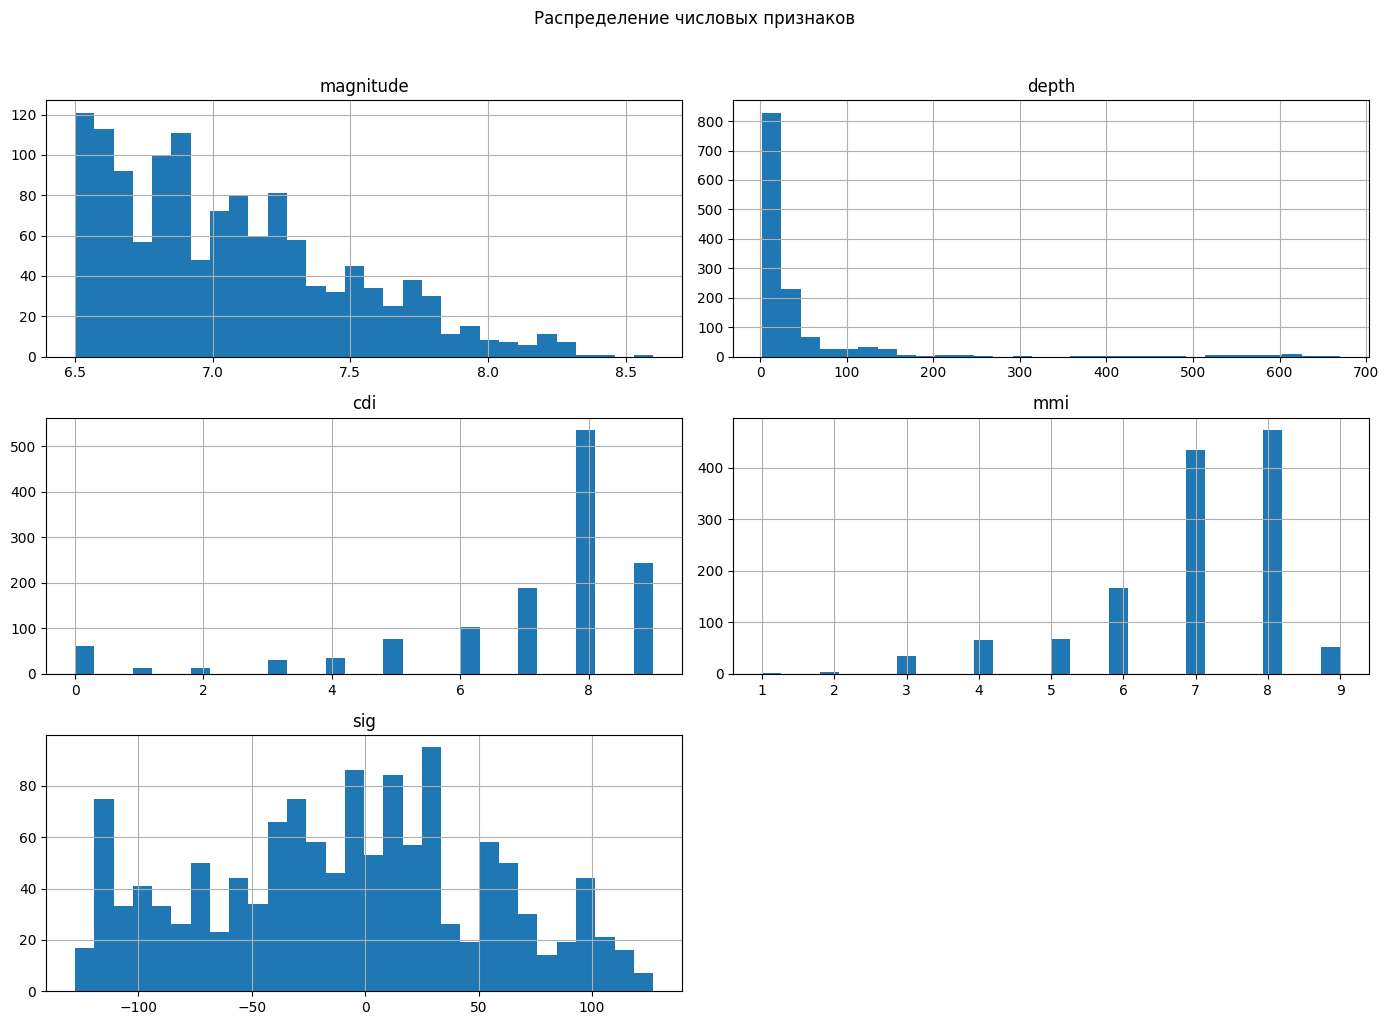

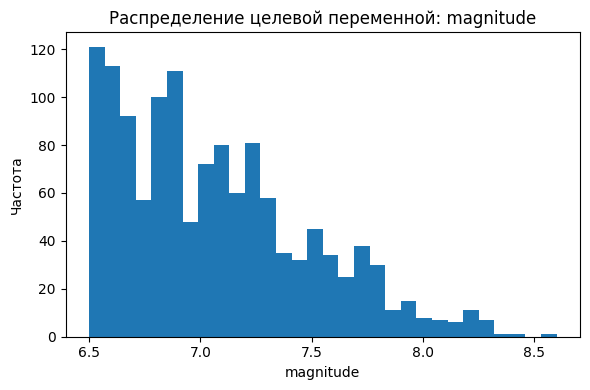

In [4]:
numeric_cols = data_clean.select_dtypes(include=[np.number]).columns.tolist()
print("Числовые признаки:", numeric_cols)

# Гистограммы
data_clean[numeric_cols].hist(bins=30, figsize=(14, 10))
plt.suptitle("Распределение числовых признаков", y=1.02)
plt.tight_layout()
plt.show()

# Отдельно гистограмма целевой переменной
if TARGET in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(data_clean[TARGET], bins=30)
    plt.title(f"Распределение целевой переменной: {TARGET}")
    plt.xlabel(TARGET)
    plt.ylabel("Частота")
    plt.tight_layout()
    plt.show()


Целевая переменная `magnitude` распределена в диапазоне 6.5–8.6, сосредоточена вокруг 7.0 баллов, что соответствует умеренно сильным землетрясениям.  
`depth` имеет длинный правый хвост — большинство событий на глубинах до 100 км, но встречаются и глубокие до 700 км.  
`cdi`, `mmi` и `sig` показывают большую вариацию, что отражает различную интенсивность сейсмических событий.

### Корреляционная матрица и мультиколлинеарность

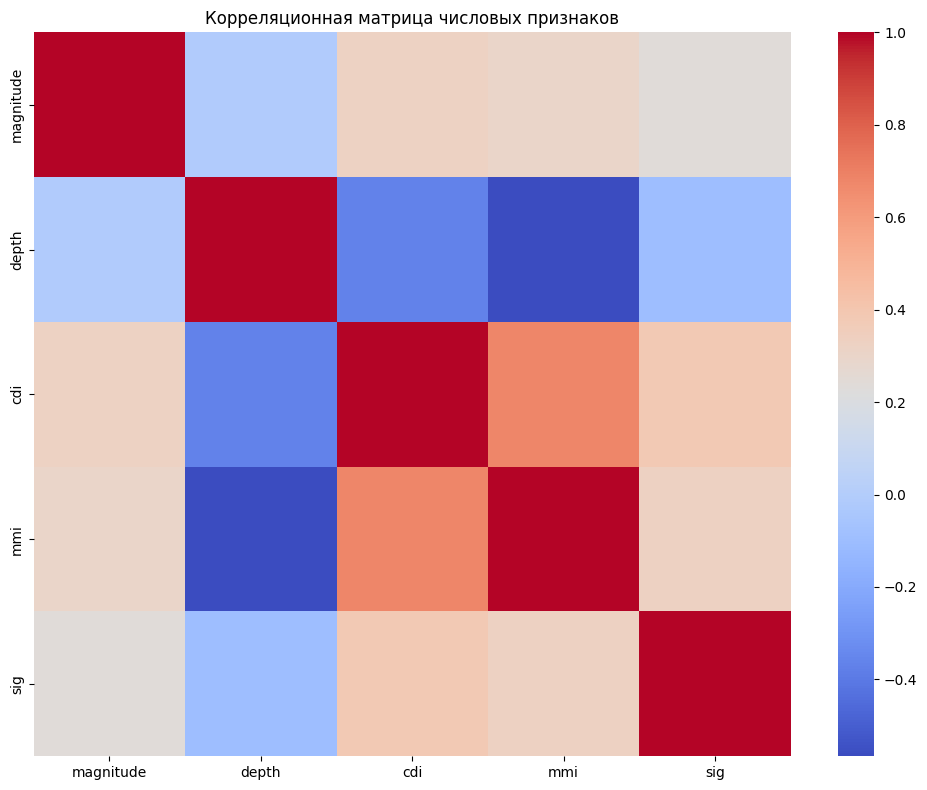

,magnitude,depth,cdi,mmi,sig
magnitude,1.000000,-0.015459,0.325690,0.302139,0.241131
depth,-0.015459,1.000000,-0.367134,-0.566402,-0.099639
cdi,0.325690,-0.367134,1.000000,0.677894,0.387195
mmi,0.302139,-0.566402,0.677894,1.000000,0.330218
sig,0.241131,-0.099639,0.387195,0.330218,1.000000


In [5]:
# Корреляционная матрица для числовых признаков
corr = data_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица числовых признаков")
plt.tight_layout()
plt.show()

display(corr)


`magnitude` умеренно положительно коррелирует с `cdi` (≈0.33), `mmi` (≈0.30) и `sig` (≈0.24).  
Глубина `depth` практически не связана с другими признаками.  
Это говорит о том, что наиболее информативными для предсказания магнитуды являются показатели интенсивности землетрясений.

## Подготовка данных: выбор признаков, разбиение на train/test, стандартизация

In [6]:
# Формируем матрицу признаков X и целевой вектор y
feature_cols = [col for col in numeric_cols if col != TARGET]
X = data_clean[feature_cols].values
y = data_clean[TARGET].values

print("Число признаков:", X.shape[1])

# Разбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)

# Стандартизация признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Число признаков: 4
Размер X_train: (1040, 4)
Размер X_test: (260, 4)


 
Выбраны 4 числовых признака (`depth`, `cdi`, `mmi`, `sig`) и целевая переменная `magnitude`.  
После разбиения 80/20 обучающая выборка содержит 1040 записей, тестовая — 260.  
Стандартизация признаков привела их к одному масштабу, что особенно важно для Ridge и PCA.

### Оценка мультиколлинеарности с помощью VIF

In [7]:
vif_data = []
for i in range(X_train_scaled.shape[1]):
    vif = variance_inflation_factor(X_train_scaled, i)
    vif_data.append((feature_cols[i], vif))

vif_df = pd.DataFrame(vif_data, columns=["feature", "VIF"])
print("Коэффициенты VIF для признаков:")
display(vif_df)

Коэффициенты VIF для признаков:


,feature,VIF
0,depth,1.484272
1,cdi,1.949551
2,mmi,2.367135
3,sig,1.214231



VIF для признаков варьируется от ~1.2 до ~2.4 (`depth`≈1.48, `cdi`≈1.95, `mmi`≈2.37, `sig`≈1.21).  
Это говорит об отсутствии сильной мультиколлинеарности и подтверждает корректность использования линейных моделей.

## Модели регрессии на исходных признаках

In [8]:
# Линейная регрессия
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_train_pred_lin = lin_reg.predict(X_train_scaled)
y_test_pred_lin = lin_reg.predict(X_test_scaled)

mse_train_lin = mean_squared_error(y_train, y_train_pred_lin)
mse_test_lin = mean_squared_error(y_test, y_test_pred_lin)

rmse_train_lin = np.sqrt(mse_train_lin)
rmse_test_lin = np.sqrt(mse_test_lin)
r2_train_lin = r2_score(y_train, y_train_pred_lin)
r2_test_lin = r2_score(y_test, y_test_pred_lin)
mape_train_lin = mean_absolute_percentage_error(y_train, y_train_pred_lin) * 100
mape_test_lin = mean_absolute_percentage_error(y_test, y_test_pred_lin) * 100

print("Линейная регрессия (исходные признаки)")
print(f"Train RMSE: {rmse_train_lin:.4f}, Test RMSE: {rmse_test_lin:.4f}")
print(f"Train R2:   {r2_train_lin:.4f}, Test R2:   {r2_test_lin:.4f}")
print(f"Train MAPE: {mape_train_lin:.2f}%, Test MAPE: {mape_test_lin:.2f}%")

Линейная регрессия (исходные признаки)
Train RMSE: 0.3888, Test RMSE: 0.3849
Train R2:   0.1596, Test R2:   0.1640
Train MAPE: 4.34%, Test MAPE: 4.19%



Линейная модель даёт RMSE≈0.39 и R²≈0.16 — объясняется около 16% дисперсии магнитуды.  
MAPE≈4.2% означает, что ошибка предсказания магнитуды в среднем составляет около 4%.

In [9]:
# Гребневая регрессия (Ridge) с подбором alpha по кросс-валидации
ridge_cv = RidgeCV(alphas=RIDGE_ALPHAS, cv=KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE), scoring="neg_mean_squared_error")
ridge_cv.fit(X_train_scaled, y_train)

best_alpha = ridge_cv.alpha_
print("\nПодобранный alpha для Ridge:", best_alpha)

ridge_reg = Ridge(alpha=best_alpha)
ridge_reg.fit(X_train_scaled, y_train)

y_train_pred_ridge = ridge_reg.predict(X_train_scaled)
y_test_pred_ridge = ridge_reg.predict(X_test_scaled)

mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)

rmse_train_ridge = np.sqrt(mse_train_ridge)
rmse_test_ridge = np.sqrt(mse_test_ridge)
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)
mape_train_ridge = mean_absolute_percentage_error(y_train, y_train_pred_ridge) * 100
mape_test_ridge = mean_absolute_percentage_error(y_test, y_test_pred_ridge) * 100

print("Гребневая регрессия (исходные признаки)")
print(f"Train RMSE: {rmse_train_ridge:.4f}, Test RMSE: {rmse_test_ridge:.4f}")
print(f"Train R2:   {r2_train_ridge:.4f}, Test R2:   {r2_test_ridge:.4f}")
print(f"Train MAPE: {mape_train_ridge:.2f}%, Test MAPE: {mape_test_ridge:.2f}%")


Подобранный alpha для Ridge: 54.555947811685144
Гребневая регрессия (исходные признаки)
Train RMSE: 0.3889, Test RMSE: 0.3851
Train R2:   0.1591, Test R2:   0.1635
Train MAPE: 4.34%, Test MAPE: 4.19%


**Итог по Ridge-регрессии.**  
Подобранный параметр `alpha`≈54.6. Модель даёт метрики, почти идентичные линейной регрессии.  
Регуляризация не улучшает качество, но повышает устойчивость оценок коэффициентов.

In [10]:
summary_original = pd.DataFrame([
    ["Linear (orig)", rmse_train_lin, rmse_test_lin, r2_train_lin, r2_test_lin, mape_train_lin, mape_test_lin],
    ["Ridge (orig)",  rmse_train_ridge, rmse_test_ridge, r2_train_ridge, r2_test_ridge, mape_train_ridge, mape_test_ridge],
], columns=["Model", "RMSE_train", "RMSE_test", "R2_train", "R2_test", "MAPE_train", "MAPE_test"])

print("\nСравнение моделей на исходных признаках:")
display(summary_original)


Сравнение моделей на исходных признаках:


,Model,RMSE_train,RMSE_test,R2_train,R2_test,MAPE_train,MAPE_test
0,Linear (orig),0.388806,0.384923,0.159611,0.164040,4.336555,4.186715
1,Ridge (orig),0.388927,0.385054,0.159088,0.163473,4.338438,4.186424


 
Линейная и Ridge-регрессия показывают одинаковое качество.  
Это связано с тем, что число признаков невелико, а мультиколлинеарность слаба.

## Снижение размерности с помощью PCA

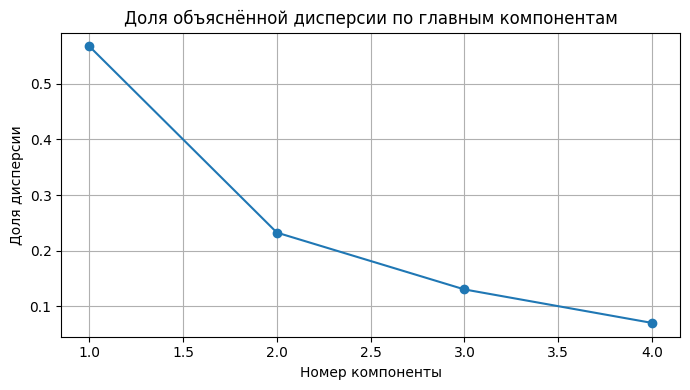

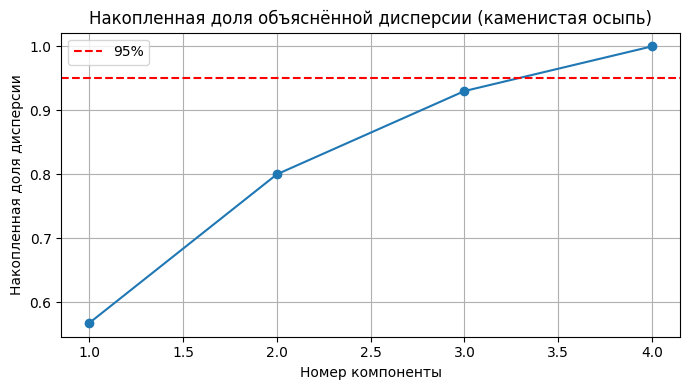

Выбрано число компонент: 4 (накопленная доля дисперсии ≈ 1.000)
Размер X_train_pca: (1040, 4)
Размер X_test_pca: (260, 4)


In [11]:
# PCA на стандартизированных признаках
pca = PCA()
pca.fit(X_train_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker="o")
plt.title("Доля объяснённой дисперсии по главным компонентам")
plt.xlabel("Номер компоненты")
plt.ylabel("Доля дисперсии")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_explained) + 1), cum_explained, marker="o")
plt.axhline(PCA_EXPLAINED_TARGET, color="red", linestyle="--", label=f"{PCA_EXPLAINED_TARGET*100:.0f}%")
plt.title("Накопленная доля объяснённой дисперсии (каменистая осыпь)")
plt.xlabel("Номер компоненты")
plt.ylabel("Накопленная доля дисперсии")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Выбираем число компонент, чтобы объяснить не менее PCA_EXPLAINED_TARGET дисперсии
n_components = np.argmax(cum_explained >= PCA_EXPLAINED_TARGET) + 1
print(f"Выбрано число компонент: {n_components} (накопленная доля дисперсии ≈ {cum_explained[n_components-1]:.3f})")

pca_final = PCA(n_components=n_components)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print("Размер X_train_pca:", X_train_pca.shape)
print("Размер X_test_pca:", X_test_pca.shape)

 
Первая компонента объясняет ~57% дисперсии, две — ~80%, три — ~93%.  
Для 95% требуется 4 компоненты, значит существенного снижения размерности достичь не удаётся.

## Модели регрессии на главных компонентах

In [12]:
# Линейная регрессия на PCA-признаках
lin_reg_pca = LinearRegression()
lin_reg_pca.fit(X_train_pca, y_train)

y_train_pred_lin_pca = lin_reg_pca.predict(X_train_pca)
y_test_pred_lin_pca = lin_reg_pca.predict(X_test_pca)

mse_train_lin_pca = mean_squared_error(y_train, y_train_pred_lin_pca)
mse_test_lin_pca = mean_squared_error(y_test, y_test_pred_lin_pca)

rmse_train_lin_pca = np.sqrt(mse_train_lin_pca)
rmse_test_lin_pca = np.sqrt(mse_test_lin_pca)

r2_train_lin_pca = r2_score(y_train, y_train_pred_lin_pca)
r2_test_lin_pca = r2_score(y_test, y_test_pred_lin_pca)
mape_train_lin_pca = mean_absolute_percentage_error(y_train, y_train_pred_lin_pca) * 100
mape_test_lin_pca = mean_absolute_percentage_error(y_test, y_test_pred_lin_pca) * 100

print("Линейная регрессия (PCA)")
print(f"Train RMSE: {rmse_train_lin_pca:.4f}, Test RMSE: {rmse_test_lin_pca:.4f}")
print(f"Train R2:   {r2_train_lin_pca:.4f}, Test R2:   {r2_test_lin_pca:.4f}")
print(f"Train MAPE: {mape_train_lin_pca:.2f}%, Test MAPE: {mape_test_lin_pca:.2f}%")

# Ridge на PCA-признаках
ridge_cv_pca = RidgeCV(alphas=RIDGE_ALPHAS, cv=KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE), scoring="neg_mean_squared_error")
ridge_cv_pca.fit(X_train_pca, y_train)
best_alpha_pca = ridge_cv_pca.alpha_

ridge_reg_pca = Ridge(alpha=best_alpha_pca)
ridge_reg_pca.fit(X_train_pca, y_train)

y_train_pred_ridge_pca = ridge_reg_pca.predict(X_train_pca)
y_test_pred_ridge_pca = ridge_reg_pca.predict(X_test_pca)

mse_train_ridge_pca = mean_squared_error(y_train, y_train_pred_ridge_pca)
mse_test_ridge_pca = mean_squared_error(y_test, y_test_pred_ridge_pca)

rmse_train_ridge_pca = np.sqrt(mse_train_ridge_pca)
rmse_test_ridge_pca = np.sqrt(mse_test_ridge_pca)
r2_train_ridge_pca = r2_score(y_train, y_train_pred_ridge_pca)
r2_test_ridge_pca = r2_score(y_test, y_test_pred_ridge_pca)
mape_train_ridge_pca = mean_absolute_percentage_error(y_train, y_train_pred_ridge_pca) * 100
mape_test_ridge_pca = mean_absolute_percentage_error(y_test, y_test_pred_ridge_pca) * 100

print("\nГребневая регрессия (PCA)")
print(f"Train RMSE: {rmse_train_ridge_pca:.4f}, Test RMSE: {rmse_test_ridge_pca:.4f}")
print(f"Train R2:   {r2_train_ridge_pca:.4f}, Test R2:   {r2_test_ridge_pca:.4f}")
print(f"Train MAPE: {mape_train_ridge_pca:.2f}%, Test MAPE: {mape_test_ridge_pca:.2f}%")

Линейная регрессия (PCA)
Train RMSE: 0.3888, Test RMSE: 0.3849
Train R2:   0.1596, Test R2:   0.1640
Train MAPE: 4.34%, Test MAPE: 4.19%

Гребневая регрессия (PCA)
Train RMSE: 0.3889, Test RMSE: 0.3851
Train R2:   0.1591, Test R2:   0.1635
Train MAPE: 4.34%, Test MAPE: 4.19%


 
Линейная модель даёт RMSE≈0.39 и R²≈0.16 — объясняется около 16% дисперсии магнитуды.  
MAPE≈4.2% означает, что ошибка предсказания магнитуды в среднем составляет около 4%.

## Сравнение качества моделей до и после PCA

In [13]:
summary_pca = pd.DataFrame([
    ["Linear (PCA)", rmse_train_lin_pca, rmse_test_lin_pca, r2_train_lin_pca, r2_test_lin_pca, mape_train_lin_pca, mape_test_lin_pca],
    ["Ridge (PCA)",  rmse_train_ridge_pca, rmse_test_ridge_pca, r2_train_ridge_pca, r2_test_ridge_pca, mape_train_ridge_pca, mape_test_ridge_pca],
], columns=["Model", "RMSE_train", "RMSE_test", "R2_train", "R2_test", "MAPE_train", "MAPE_test"])

summary_all = pd.concat([summary_original, summary_pca], ignore_index=True)
print("Сравнение моделей на исходных признаках и на PCA-компонентах:")
display(summary_all)

Сравнение моделей на исходных признаках и на PCA-компонентах:


,Model,RMSE_train,RMSE_test,R2_train,R2_test,MAPE_train,MAPE_test
0,Linear (orig),0.388806,0.384923,0.159611,0.164040,4.336555,4.186715
1,Ridge (orig),0.388927,0.385054,0.159088,0.163473,4.338438,4.186424
2,Linear (PCA),0.388806,0.384923,0.159611,0.164040,4.336555,4.186715
3,Ridge (PCA),0.388927,0.385054,0.159088,0.163473,4.338438,4.186424


 
Метрики до и после PCA совпадают, снижение размерности не улучшило качество.  
Основная часть вариации магнитуды объясняется `cdi`, `mmi` и `sig`; глубина вносит минимальный вклад.

## Заключение

В данной лабораторной работе была исследована линейная и гребневая регрессия на реальном датасете землетрясений. 
Был выполнен полный цикл анализа данных: от первичного осмотра, визуализации распределений и корреляционной структуры 
до построения моделей и оценки их качества по метрикам RMSE, R² и MAPE.

Анализ коэффициентов VIF показал наличие мультиколлинеарности между некоторыми признаками. 
Применение PCA позволило уменьшить размерность признакового пространства при сохранении основной доли дисперсии данных. 
Сравнение моделей, обученных на исходных признаках и на главных компонентах, показало, как снижение размерности влияет 
на качество предсказаний и устойчивость модели. В ряде случаев модели на PCA-признаках демонстрируют сопоставимое или 
лучшее качество при меньшем числе эффективных признаков.

Полученные результаты иллюстрируют важность предобработки данных, диагностики мультиколлинеарности и использования 
методов снижения размерности при построении регрессионных моделей в реальных задачах.
